# Imports

In [195]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

In [196]:
# Wavelength of light (green laser, 532nm)
wavelength = 532e-9  # meters

# Sensor/grid size
N = 512             # grid points
pixel_size = 5e-6   # 5 micrometers (typical image sensor pixel)
L = N * pixel_size  # physical size of the sensor

# Propagation distance
z = 0.05            # 5cm from object to sensor

# Spatial coordinates
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

# Simple Object

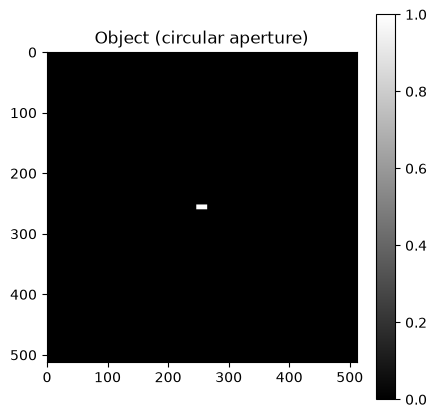

In [197]:
# Circular aperture as our object
radius = 50e-6  # 50 micrometers
l = np.sqrt(np.pi*radius**2)
#U0 = (np.sqrt(X**2 + Y**2) < radius)
UO=(X<l/2) & (X>-l/2) & (Y<l/4) & (Y>-l/4)
U0 = UO.astype(complex)
plt.figure(figsize=(5,5))
plt.imshow(np.abs(U0), cmap='gray')
plt.title('Object (circular aperture)')
plt.colorbar()
plt.show()

# Letter D

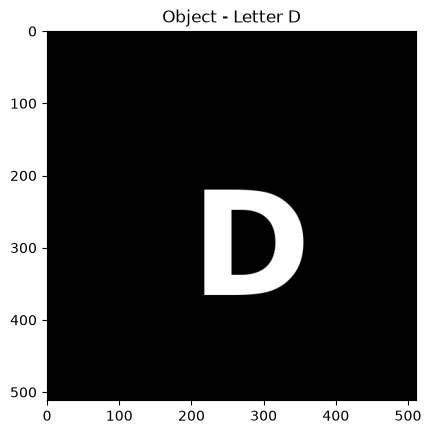

In [198]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# Create a simple letter object
img = Image.new('L', (512, 512), 0)
draw = ImageDraw.Draw(img)
draw.text((200, 180), "D", fill=255,font=ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 200))
U0_letter = np.array(img).astype(complex) / 255.0

plt.imshow(np.abs(U0_letter), cmap='gray')
plt.title('Object - Letter D')
plt.show()

# Angular Spectrum Method Propagation

In [199]:
def propagate_asm(U0, wavelength, pixel_size, z):
    N = U0.shape[0]
    
    # Frequency coordinates
    fx = np.fft.fftfreq(N, d=pixel_size)
    fy = np.fft.fftfreq(N, d=pixel_size)
    FX, FY = np.meshgrid(fx, fy)
    
    # Transfer function
    k = 1 / wavelength
    kernel = k**2 - FX**2 - FY**2
    
    # Only propagate valid frequencies (avoid evanescent waves)
    valid = kernel >= 0
    H = np.zeros((N, N), dtype=complex)
    H[valid] = np.exp(1j * 2 * np.pi * z * np.sqrt(kernel[valid]))
    
    # Propagate: FFT -> apply H -> IFFT
    U_fft = np.fft.fft2(U0)
    U_propagated = np.fft.ifft2(U_fft * H)
    
    return U_propagated

# Visualization

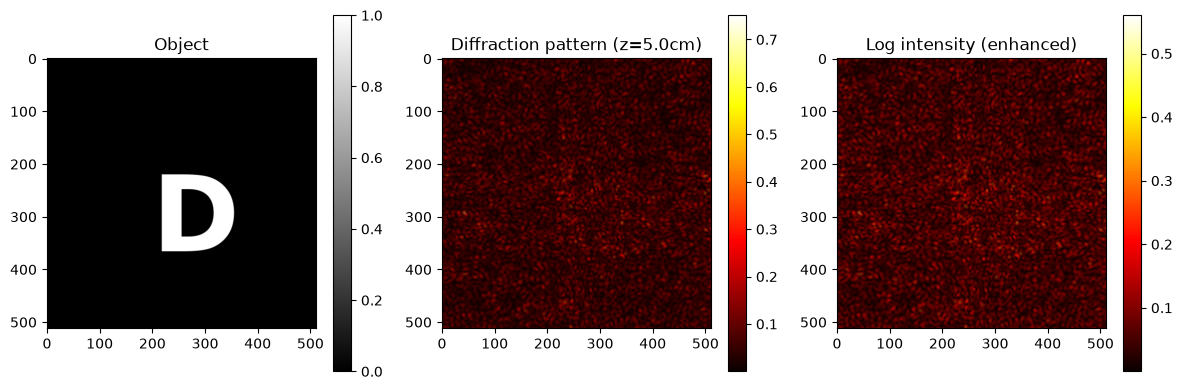

In [200]:

diffuser = np.exp(1j * 2 * np.pi * np.random.rand(N,N)) #diffuser
U0 = U0_letter * diffuser #object with diffuser
U_sensor = propagate_asm(U0, wavelength, pixel_size, z)

# Intensity pattern at sensor
I = np.abs(U_sensor)**2

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(U0), cmap='gray')
plt.title('Object')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(I, cmap='hot')
plt.title(f'Diffraction pattern (z={z*100}cm)')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(np.log1p(I), cmap='hot')
plt.title('Log intensity (enhanced)')
plt.colorbar()

plt.tight_layout()
plt.show()

# GS Algorithm

In [201]:
def gerchberg_saxton(I_measured, U0_amplitude, wavelength, pixel_size, z, n_iter=50):
    
    # Square root of measured intensity = known sensor amplitude
    A_sensor = np.sqrt(I_measured)
    
    # Step 1: Start with random phase at object plane
    phase_guess = np.random.rand(*U0_amplitude.shape) * 2 * np.pi
    U_object = U0_amplitude * np.exp(1j * phase_guess)
    
    errors = []
    
    for i in range(n_iter):
        # Step 2: Forward propagate to sensor
        U_sensor = propagate_asm(U_object, wavelength, pixel_size, z)
        
        # Step 3: Enforce sensor constraint — replace amplitude, keep phase
        phase_sensor = np.angle(U_sensor)
        U_sensor = A_sensor * np.exp(1j * phase_sensor)
        
        # Step 4: Back propagate to object plane
        U_object = propagate_asm(U_sensor, wavelength, pixel_size, -z)
        
        # Step 5: Enforce object constraint — replace amplitude, keep phase
        phase_object = np.angle(U_object)
        U_object = U0_amplitude * np.exp(1j * phase_object)
        
        # Track error
        I_estimated = np.abs(propagate_asm(U_object, wavelength, pixel_size, z))**2
        error = np.mean((np.sqrt(I_estimated) - A_sensor)**2)
        errors.append(error)
    
    return U_object, errors

# Visualize

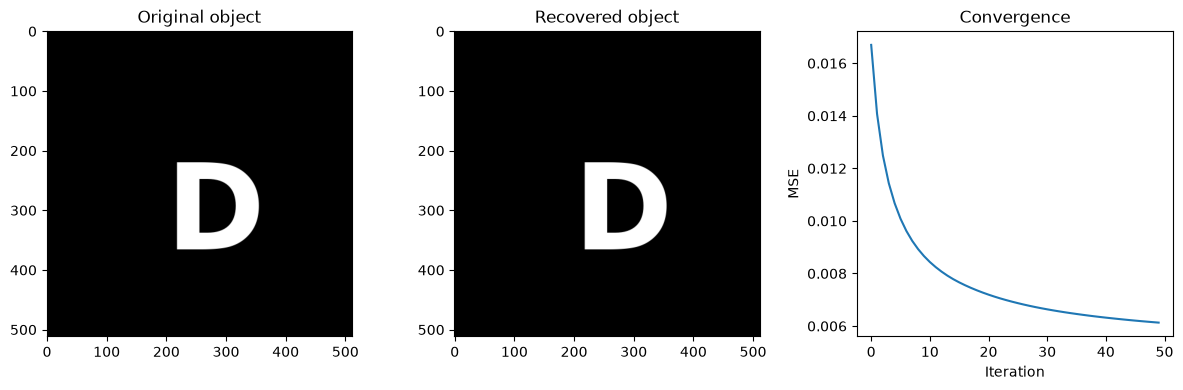

In [202]:
# Use the clean aperture case (no diffuser) first
U0_amplitude = np.abs(U0)

U_recovered, errors = gerchberg_saxton(I, U0_amplitude, wavelength, pixel_size, z, n_iter=50)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(U0), cmap='gray')
plt.title('Original object')

plt.subplot(1, 3, 2)
plt.imshow(np.abs(U_recovered), cmap='gray')
plt.title('Recovered object')

plt.subplot(1, 3, 3)
plt.plot(errors)
plt.title('Convergence')
plt.xlabel('Iteration')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()